## Modeling Objective

The objective is to use employee characteristics to estimate the probability of employee attrition. Because `Attrition` is a binary outcome, logistic regression is used as an interpretable classification model.

In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

df = pd.read_csv("employee_attrition_data.csv")
df.head()

,Age,MonthlyIncome,YearsAtCompany,JobSatisfaction,Overtime,DistanceFromHome,Attrition
0,60,10223,18,1,1,12,0
1,50,6880,3,1,1,15,1
2,36,6607,3,4,1,17,0
3,64,8226,10,3,0,10,0
4,29,5873,4,2,1,6,1


## Variable Descriptions

The model uses the following employee characteristics to predict employee attrition.

### Predictor Variables

| Variable | Description |
|---|---|
| `MonthlyIncome` | Employee's monthly income. |
| `YearsAtCompany` | Number of years the employee has worked at the company. |
| `JobSatisfaction` | Employee's job satisfaction rating. On a scale from 1-4. |
| `Overtime` | Indicates whether the employee works overtime (`1 = Yes`, `0 = No`). |
| `DistanceFromHome` | Distance between the employee's home and workplace. |

### Target Variable

| Variable | Description |
|---|---|
| `Attrition` | Indicates whether the employee left the company (`1 = Yes`, `0 = No`). |

# Fit the logistic regression

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split


X = df.drop(columns = "Attrition")
y = df["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(400, 6)
(100, 6)


### Fit the model

In [3]:
model = LogisticRegression(max_iter = 1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

### Get the coefficients of the model, and odds-ratio of each coefficient

In [15]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0],
    "Odds_Ratio": np.exp(model.coef_[0])
})

coefficients["Percentage Higher/Lower Odds of Attrition"] = (
    (coefficients["Odds_Ratio"] - 1) * 100).round(6)

coefficients

,Feature,Coefficient,Odds_Ratio,Percentage Higher/Lower Odds of Attrition
0,Age,0.003634,1.003641,0.364066
1,MonthlyIncome,-0.000003,0.999997,-0.000303
2,YearsAtCompany,-0.122681,0.884546,-11.545383
3,JobSatisfaction,-0.258391,0.772293,-22.770683
4,Overtime,0.174429,1.190566,19.056571
5,DistanceFromHome,0.044197,1.045188,4.518772


# Interpreting the coefficients of the model


- **Job Satisfaction:** A one-point increase in job satisfaction is associated with approximately **22.5% lower odds** of attrition, holding the other variables constant.

- **Years at Company:** Each additional year at the company is associated with approximately **11.5% lower odds** of attrition.

- **Overtime:** Employees working overtime have approximately **17.9% higher odds** of attrition compared with employees not working overtime.

- **Distance From Home:** Each additional mile from home is associated with approximately **4.5% higher odds** of attrition.

- **Age:** Each additional year of age is associated with approximately **0.36% higher odds** of attrition.

- **Monthly Income:** The estimated association between monthly income and attrition is very small on a per-dollar basis.


# Model Evaluation

In [5]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Stay", "Actual Leave"],
    columns=["Predicted Stay", "Predicted Leave"]
)

cm_df

,Predicted Stay,Predicted Leave
Actual Stay,69,3
Actual Leave,20,8


In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Accuracy: 0.77
Precision: 0.7272727272727273
Recall: 0.2857142857142857
F1: 0.41025641025641024


# Findings

The logistic regression model achieved an overall accuracy of 77%, meaning that it correctly classified approximately 77% of employees as either staying with or leaving the company.

However, accuracy alone does not tell the full story. The model's precision was 72.7%, meaning that when the model predicted an employee would leave, approximately 73% of those predictions were correct.

The model's recall was only 28.6%, meaning that it identified approximately 29% of the employees who actually left the company. In other words, the model missed roughly 71% of the actual attrition cases.

The F1 score of 41.0% reflects the tradeoff between precision and recall. Although the model's precision is relatively strong, its low recall indicates that it is not particularly effective at identifying employees who are actually at risk of leaving.

# Business Interpretation

For an attrition-risk application, the low recall is an important limitation. If the goal is to identify as many potential departures as possible so that an organization can investigate retention opportunities, this model would likely require improvement. A different classification threshold, additional predictors, or a more flexible model could potentially improve recall.


# Tuning the model - Regularization

The initial logistic regression model's relatively low recall indicated that there is room to improve the model's ability to identify employees who actually left the company.

To investigate whether regularization could improve model performance and generalization, I compared L1 and L2 regularization using a grid search across multiple values of C.

L1 and L2 regularization make different assumptions about the importance of predictors. L1 regularization can shrink some coefficients to zero, effectively performing feature selection, while L2 regularization shrinks coefficients toward zero while generally retaining all predictors.

Because it was not known in advance which approach would perform better for this dataset, both were evaluated using cross-validation across a range of regularization strengths. Model performance was compared using precision, recall, F1 score, and accuracy.

The goal was not simply to maximize accuracy, but to determine whether regularization could produce a model that better balanced identifying employees at risk of attrition with avoiding unnecessary false positives.

In [7]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "penalty": ["l1", "l2"],
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear"]
}

grid_search = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV Recall:", grid_search.best_score_)

Best parameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV Recall: 0.2608695652173913


In [8]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]

results = []

for c in C_values:
    model = LogisticRegression(
        #solver = 'liblinear',
        penalty="l2",
        C=c,
        max_iter=1000
    )
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    results.append({
        "C": c,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df

,C,Accuracy,Precision,Recall,F1
0,0.001,0.72,0.500000,0.071429,0.125000
1,0.010,0.75,0.714286,0.178571,0.285714
2,0.100,0.75,0.636364,0.250000,0.358974
3,1.000,0.77,0.727273,0.285714,0.410256
4,10.000,0.77,0.727273,0.285714,0.410256
5,100.000,0.77,0.727273,0.285714,0.410256


In [9]:
best_model = grid_search.best_estimator_

y_pred_grid = best_model.predict(X_test)

print("Test F1:", f1_score(y_test, y_pred_grid))
print("Test Accuracy:", accuracy_score(y_test, y_pred_grid))
print("Test Precision:", precision_score(y_test, y_pred_grid))
print("Test Recall:", recall_score(y_test, y_pred_grid))

Test F1: 0.41025641025641024
Test Accuracy: 0.77
Test Precision: 0.7272727272727273
Test Recall: 0.2857142857142857


# Tuning Interpretation

L1 regularization with C=1 produced the highest cross-validated recall score of 0.261. However, when evaluated on the held-out test set, it did not outperform the original L2 model. I therefore retained the L2 model as the preferred model.

# Changing the threshold of predicting attrition.

In [10]:
# Get the model
model_l2 = LogisticRegression(
    penalty="l2",
    C=1,
    solver="lbfgs",
    max_iter=1000
)

model_l2.fit(X_train, y_train)

#Get the probabilities
y_prob = model_l2.predict_proba(X_test)[:, 1]

# Do a manual search across the following thresholds and add them to a dataframe
thresholds = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]
results = []

for threshold in thresholds:
    y_pred = (y_prob >= threshold).astype(int)

    results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0)
    })

threshold_results = pd.DataFrame(results)

threshold_results.style.format({
    "Threshold": "{:.0%}",
    "Accuracy": "{:.1%}",
    "Precision": "{:.1%}",
    "Recall": "{:.1%}",
    "F1": "{:.1%}"
})


,Threshold,Accuracy,Precision,Recall,F1
0,20%,62.0%,41.1%,82.1%,54.8%
1,30%,68.0%,44.7%,60.7%,51.5%
2,40%,79.0%,66.7%,50.0%,57.1%
3,50%,77.0%,72.7%,28.6%,41.0%
4,60%,73.0%,66.7%,7.1%,12.9%
5,70%,72.0%,0.0%,0.0%,0.0%
6,80%,72.0%,0.0%,0.0%,0.0%


# Threshold Analysis

The threshold analysis demonstrates that model performance is not determined by a single accuracy value; changing the classification threshold changes the balance between identifying true attrition cases and generating false alarms. The appropriate threshold should therefore reflect the organization's tolerance for false positives and false negatives.

# Interactive Classification Threshold Widget

The visualization demonstrates how the classification threshold affects employee attrition predictions. Each point represents an employee's predicted probability of attrition, while point colors identify true positives, true negatives, false positives, and false negatives. Adjusting the threshold updates the classification results, confusion matrix, and evaluation metrics in real time.

This illustrates the tradeoff between precision and recall and demonstrates why the optimal classification threshold should be informed by the business cost of false positives versus false negatives rather than automatically assuming a 0.50 threshold.

The visualization demonstrates that the classification threshold is a business decision rather than a fixed property of the model.

FloatSlider(value=0.5, description='Threshold:', layout=Layout(width='400px'), max=0.95, min=0.05, step=0.01, …

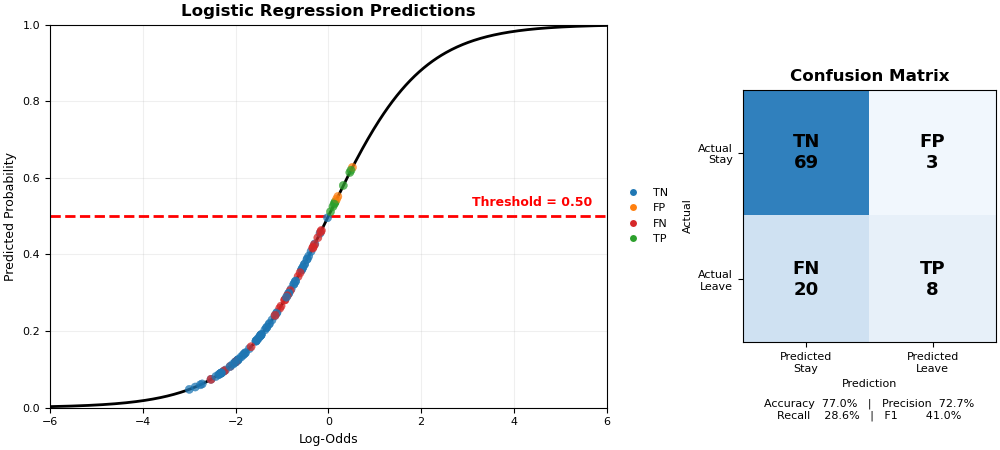

In [14]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from sklearn.metrics import confusion_matrix


# =========================================================
# 1. MODEL PREDICTIONS
# =========================================================

y_prob = model_l2.predict_proba(X_test)[:, 1]
y_actual = np.asarray(y_test)


# =========================================================
# 2. SIGMOID
# =========================================================

x = np.linspace(-6, 6, 500)
sigmoid = 1 / (1 + np.exp(-x))

p = np.clip(y_prob, 0.001, 0.999)
x_points = np.log(p / (1 - p))


# =========================================================
# 3. FIGURE — COMPACT
# =========================================================

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(10, 4.5),
    gridspec_kw={"width_ratios": [2.2, 1]},
    constrained_layout=True
)


# =========================================================
# LEFT — SIGMOID
# =========================================================

ax1.plot(
    x,
    sigmoid,
    linewidth=2,
    color="black"
)

ax1.set_xlim(-6, 6)
ax1.set_ylim(0, 1)

ax1.set_xlabel("Log-Odds", fontsize=9)
ax1.set_ylabel("Predicted Probability", fontsize=9)

ax1.set_title(
    "Logistic Regression Predictions",
    fontsize=12,
    fontweight="bold"
)

ax1.tick_params(axis="both", labelsize=8)
ax1.grid(alpha=0.2)


# =========================================================
# CLASSIFICATION
# =========================================================

threshold = 0.50
y_pred = (y_prob >= threshold).astype(int)


def get_point_colors(y_actual, y_pred):

    colors = []

    for actual, predicted in zip(y_actual, y_pred):

        if actual == 0 and predicted == 0:
            colors.append("tab:blue")       # TN

        elif actual == 0 and predicted == 1:
            colors.append("tab:orange")     # FP

        elif actual == 1 and predicted == 0:
            colors.append("tab:red")        # FN

        else:
            colors.append("tab:green")      # TP

    return colors


scatter = ax1.scatter(
    x_points,
    y_prob,
    s=35,
    c=get_point_colors(y_actual, y_pred),
    alpha=0.75,
    edgecolor="black",
    linewidth=0.3,
    zorder=3
)


# =========================================================
# LEGEND
# =========================================================

legend_handles = [
    plt.Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor="tab:blue",
        markersize=6,
        label="TN"
    ),
    plt.Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor="tab:orange",
        markersize=6,
        label="FP"
    ),
    plt.Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor="tab:red",
        markersize=6,
        label="FN"
    ),
    plt.Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor="tab:green",
        markersize=6,
        label="TP"
    )
]

ax1.legend(
    handles=legend_handles,
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    fontsize=8,
    frameon=False
)


# =========================================================
# THRESHOLD
# =========================================================

threshold_line = ax1.axhline(
    threshold,
    color="red",
    linestyle="--",
    linewidth=2
)

threshold_text = ax1.text(
    5.7,
    threshold + 0.025,
    f"Threshold = {threshold:.2f}",
    ha="right",
    fontsize=9,
    fontweight="bold",
    color="red"
)


# =========================================================
# RIGHT — CONFUSION MATRIX
# =========================================================

tn, fp, fn, tp = confusion_matrix(
    y_actual,
    y_pred
).ravel()

cm = np.array([
    [tn, fp],
    [fn, tp]
])

cm_image = ax2.imshow(
    cm,
    cmap="Blues",
    vmin=0,
    vmax=len(y_actual)
)

ax2.set_xticks([0, 1])
ax2.set_xticklabels(
    ["Predicted\nStay", "Predicted\nLeave"],
    fontsize=8
)

ax2.set_yticks([0, 1])
ax2.set_yticklabels(
    ["Actual\nStay", "Actual\nLeave"],
    fontsize=8
)

ax2.set_xlabel("Prediction", fontsize=8)
ax2.set_ylabel("Actual", fontsize=8)

ax2.set_title(
    "Confusion Matrix",
    fontsize=12,
    fontweight="bold"
)


# =========================================================
# MATRIX NUMBERS
# =========================================================

cell_text = []

for i in range(2):

    row = []

    for j in range(2):

        text = ax2.text(
            j,
            i,
            "",
            ha="center",
            va="center",
            fontsize=13,
            fontweight="bold"
        )

        row.append(text)

    cell_text.append(row)


# =========================================================
# METRICS
# =========================================================

metrics_text = ax2.text(
    0.5,
    -0.22,
    "",
    transform=ax2.transAxes,
    ha="center",
    va="top",
    fontsize=8
)


# =========================================================
# UPDATE FUNCTION
# =========================================================

def update_visualization(change=None):

    threshold = threshold_slider.value

    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_actual,
        y_pred
    ).ravel()

    cm = np.array([
        [tn, fp],
        [fn, tp]
    ])

    # Update point colors
    scatter.set_color(
        get_point_colors(y_actual, y_pred)
    )

    # Update threshold line
    threshold_line.set_ydata(
        [threshold, threshold]
    )

    threshold_text.set_position(
        (5.7, min(threshold + 0.025, 0.96))
    )

    threshold_text.set_text(
        f"Threshold = {threshold:.2f}"
    )

    # Update confusion matrix
    cm_image.set_data(cm)

    # Update numbers
    cell_text[0][0].set_text(f"TN\n{tn}")
    cell_text[0][1].set_text(f"FP\n{fp}")
    cell_text[1][0].set_text(f"FN\n{fn}")
    cell_text[1][1].set_text(f"TP\n{tp}")

    # Metrics
    accuracy = (tp + tn) / len(y_actual)

    precision = (
        tp / (tp + fp)
        if tp + fp > 0
        else 0
    )

    recall = (
        tp / (tp + fn)
        if tp + fn > 0
        else 0
    )

    f1 = (
        2 * precision * recall / (precision + recall)
        if precision + recall > 0
        else 0
    )

    metrics_text.set_text(
        f"Accuracy  {accuracy:.1%}   |   "
        f"Precision  {precision:.1%}\n"
        f"Recall    {recall:.1%}   |   "
        f"F1        {f1:.1%}"
    )

    fig.canvas.draw_idle()


# =========================================================
# SLIDER
# =========================================================

threshold_slider = widgets.FloatSlider(
    value=0.50,
    min=0.05,
    max=0.95,
    step=0.01,
    description="Threshold:",
    continuous_update=True,
    readout_format=".2f",
    style={"description_width": "70px"},
    layout=widgets.Layout(width="400px")
)

threshold_slider.observe(
    update_visualization,
    names="value"
)

update_visualization()

display(threshold_slider)

plt.show()